# Baselines: how well can simple rules predict congestion?

Before training neural networks, we need to know what a **trivial** predictor achieves on the same task.
A model is only useful if it clearly beats these numbers.

**Task (from `preprocess.ipynb`):** given the last 2 hours (24 × 5-min readings) of one sensor, predict whether its
flow in the next 5 minutes will be **Low (0)**, **Medium (1)** or **High (2)**, using that sensor's own thresholds.

| Baseline | Rule | Uses training data? |
|---|---|---|
| Majority class | Always predict the most common training class | class counts only |
| Persistence | Next class = class of the **last** reading in the window | no |
| 15-min average | Next class = class of the mean of the last 3 readings | no |
| Linear trend | Extrapolate the last change one step ahead, then classify | no |
| Logistic regression | Linear classifier on the 72 flattened inputs | yes (fitted) |

The first four are rules with nothing to learn. Logistic regression is the simplest *learned* model.
If the neural networks can't beat it, their extra complexity isn't paying off.

All scores are on the **test set** (the last 20 % of the timeline), exactly as the neural networks will be evaluated.

## 0 · Setup

In [1]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Paths & Config
PROJECT = os.path.abspath(".")  # run the notebooks from the repository root

DATA_DIR    = os.path.join(PROJECT, "data")
RESULTS_DIR = os.path.join(PROJECT, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

DATA_FILE    = os.path.join(DATA_DIR, "traffic_flow_preprocessed.npz")
RESULTS_FILE = os.path.join(RESULTS_DIR, "baseline_results.json")

CLASS_NAMES = ["Low", "Medium", "High"]
FLOW = 0            # feature index of flow
LOGREG_SAMPLES = 200_000
SEED = 42

## 1 · Load the preprocessed data

Everything comes from the file `preprocess.ipynb` saved. The rule-based baselines need the flow values in
**vehicles per 5 minutes**, not standardised units, so we keep `feature_mean` / `feature_std` to undo the scaling.
The scaling is per sensor, so `feature_mean` / `feature_std` have shape (170, 3), one row per sensor.
They also need each sensor's thresholds (`low_th`, `high_th`) to turn a flow value into a class.

In [2]:
d = np.load(DATA_FILE)
X_train, y_train = d["X_train_seq"], d["y_train"]
X_test, y_test = d["X_test_seq"], d["y_test"]
sensor_test = d["sensor_test"]
mean, std = d["feature_mean"], d["feature_std"]
low_th, high_th = d["low_th"], d["high_th"]

print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print("Test class share:", np.round(np.bincount(y_test) / len(y_test), 3))

Train: (2425050, 24, 3)   Test: (606390, 24, 3)
Test class share: [0.337 0.327 0.336]


## 2 · Helpers

* `flow_history` undoes the per-sensor standardisation for the flow feature → shape `(samples, 24)` in vehicles / 5 min.
* `flow_to_class` applies the **same** rule as `preprocess.ipynb`, with each sample's own sensor thresholds:
  ≤ 33rd percentile → Low, ≤ 66th → Medium, otherwise High.
* `evaluate` computes the metrics used for every model in this project:
  accuracy, and **macro-F1** (the F1 of each class, averaged). Macro-F1 shows whether a predictor is good
  across all three classes rather than just the most frequent one.

In [3]:
def flow_history(X, sensors):
    # Standardised flow -> vehicles / 5 min, shape (samples, 24), using each sample's sensor statistics
    return X[:, :, FLOW] * std[sensors, FLOW][:, None] + mean[sensors, FLOW][:, None]


def flow_to_class(flow, sensors):
    lo, hi = low_th[sensors], high_th[sensors]
    return np.where(flow <= lo, 0, np.where(flow <= hi, 1, 2)).astype(np.int8)


results, predictions = {}, {}

def evaluate(name, y_pred):
    results[name] = {
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "macro_f1": float(f1_score(y_test, y_pred, average="macro")),
    }
    predictions[name] = y_pred
    print(f"{name:<20} accuracy {results[name]['accuracy']:.4f}   macro-F1 {results[name]['macro_f1']:.4f}")


flow_test = flow_history(X_test, sensor_test)

## 3 · Rule-based baselines

**Majority class.** The dumbest possible predictor. The classes are balanced by construction (≈ ⅓ each),
so this should land near 33 %, which is the "random guessing" level.

**Persistence.** Traffic changes slowly, so the flow in the next 5 minutes is usually close to the flow right now.
This is the standard baseline in traffic forecasting, and often a surprisingly strong one.

**15-min average.** Averages the last 3 readings to smooth out noise from single readings.

**Linear trend.** Assumes the last change continues: `next ≈ last + (last − previous)`. This tests whether short-term
momentum helps.

In [4]:
majority = np.bincount(y_train).argmax()
evaluate("Majority class", np.full_like(y_test, majority))

evaluate("Persistence", flow_to_class(flow_test[:, -1], sensor_test))

evaluate("15-min average", flow_to_class(flow_test[:, -3:].mean(axis=1), sensor_test))

trend = flow_test[:, -1] + (flow_test[:, -1] - flow_test[:, -2])
evaluate("Linear trend", flow_to_class(trend, sensor_test))

Majority class       accuracy 0.3363   macro-F1 0.1678
Persistence          accuracy 0.8728   macro-F1 0.8721
15-min average       accuracy 0.8808   macro-F1 0.8804
Linear trend         accuracy 0.8066   macro-F1 0.8043


## 4 · Logistic regression: the simplest learned model

A linear classifier on the flattened window (24 steps × 3 features = 72 inputs). It learns from data, but it can
only draw straight-line boundaries between classes.

Fitting on all 2.4 million training samples adds little for a linear model, so a random **200,000-sample** subset
is used to keep this fast. Evaluation still uses the **full** test set.

The model doesn't know which sensor a sample comes from, and it doesn't need to: the inputs are standardised per
sensor, so "+1" already means "busier than this sensor's normal", matching the per-sensor labels.

In [5]:
rng = np.random.default_rng(SEED)
idx = rng.choice(len(X_train), size=LOGREG_SAMPLES, replace=False)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train[idx].reshape(len(idx), -1), y_train[idx])

evaluate("Logistic regression", logreg.predict(X_test.reshape(len(X_test), -1)).astype(np.int8))

Logistic regression  accuracy 0.8724   macro-F1 0.8717


## 5 · Comparison

The **bar to beat** is the best score in this table. Any neural network in the following notebooks should be
compared against it, not just against 33 %.

,accuracy,macro_f1
15-min average,0.8808,0.8804
Persistence,0.8728,0.8721
Logistic regression,0.8724,0.8717
Linear trend,0.8066,0.8043
Majority class,0.3363,0.1678


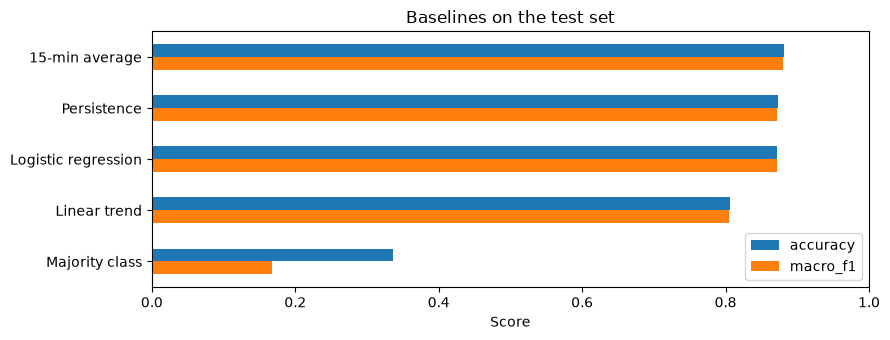

In [6]:
table = pd.DataFrame(results).T.sort_values("macro_f1", ascending=False)
display(table.style.format("{:.4f}"))

ax = table.plot.barh(figsize=(9, 3.5), xlim=(0, 1))
ax.invert_yaxis()
ax.set_title("Baselines on the test set")
ax.set_xlabel("Score")
plt.tight_layout()
plt.show()

### What these numbers mean

* **Majority class ≈ 34 %:** the classes are balanced, so guessing gets about a third right. Its macro-F1 is
  much lower because it never predicts two of the three classes.
* **Persistence and 15-min average ≈ 87–88 %:** most of the time, traffic in the next 5 minutes stays in the same
  band. **This is the real bar to beat.** A model that scores 88 % has learned nothing beyond "stay the same".
* **Linear trend is worse than persistence.** Single 5-minute changes are mostly noise, so extrapolating them
  overshoots.
* **Logistic regression roughly matches the rules** but doesn't clearly beat them. A linear model on the raw window
  mostly relearns "persistence". Beating ~88 % needs a model that captures non-linear patterns, such as the daily
  rush-hour shape, which is the job of the neural networks.
* **Why per-sensor scaling matters here:** with one global scaling (an earlier version of the preprocessing), this same
  logistic regression scored only **69 %**. A flow of 200 is *High* on a quiet ramp but *Low* on a busy freeway, so
  without per-sensor scaling the same input has different correct answers.

**Takeaway for the neural networks:** the number to beat is the best row of the table above.

## 6 · Where do the rules go wrong?

The confusion matrix of the strongest rule-based baseline shows **which** mistakes it makes. Errors are expected
almost only between *neighbouring* classes (Low ↔ Medium, Medium ↔ High): the flow near a threshold can tip either way
in 5 minutes. Medium is usually the hardest class, because it has a boundary on both sides.

Best rule-based baseline: 15-min average

              precision    recall  f1-score   support

         Low     0.9559    0.9427    0.9492    204308
      Medium     0.8177    0.8197    0.8187    198136
        High     0.8681    0.8782    0.8731    203946

    accuracy                         0.8808    606390
   macro avg     0.8806    0.8802    0.8804    606390
weighted avg     0.8812    0.8808    0.8810    606390



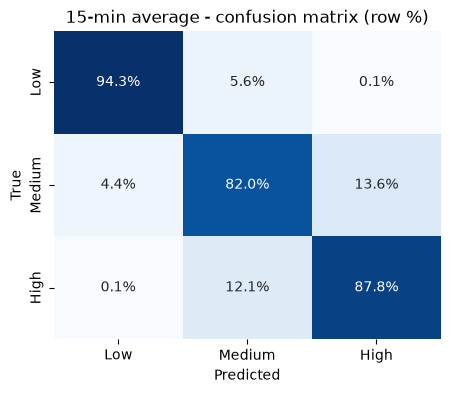

In [7]:
rule_names = ["Persistence", "15-min average", "Linear trend"]
best_rule = max(rule_names, key=lambda n: results[n]["macro_f1"])
y_best = predictions[best_rule]

print(f"Best rule-based baseline: {best_rule}\n")
print(classification_report(y_test, y_best, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_test, y_best)
cm_pct = cm / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_pct, annot=True, fmt=".1%", cmap="Blues", cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"{best_rule} - confusion matrix (row %)")
plt.show()

## 7 · Per-sensor accuracy

The overall score hides differences between sensors. Some detectors have smooth, predictable traffic, others are
noisy. This histogram shows the spread for the best rule-based baseline. The sensors at the low end are where a
learned model has the most room to improve.

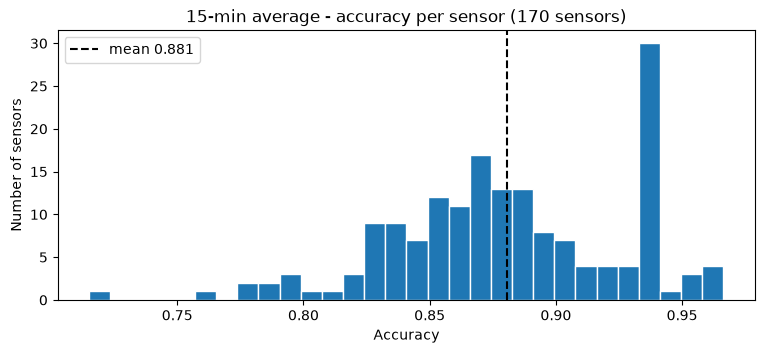

Hardest sensors: {147: 0.715, 49: 0.758, 94: 0.774, 155: 0.781, 79: 0.789}
Easiest sensors: {144: 0.966, 154: 0.966, 116: 0.964, 60: 0.964, 153: 0.958}


In [8]:
per_sensor = pd.Series(y_best == y_test).groupby(sensor_test).mean()

plt.figure(figsize=(9, 3.5))
plt.hist(per_sensor, bins=30, color="tab:blue", edgecolor="white")
plt.axvline(per_sensor.mean(), color="black", ls="--", label=f"mean {per_sensor.mean():.3f}")
plt.xlabel("Accuracy"); plt.ylabel("Number of sensors")
plt.title(f"{best_rule} - accuracy per sensor (170 sensors)")
plt.legend()
plt.show()

print("Hardest sensors:", per_sensor.nsmallest(5).round(3).to_dict())
print("Easiest sensors:", per_sensor.nlargest(5).round(3).to_dict())

## 8 · Save results

The scores are saved to `baseline_results.json`, so the model-comparison notebook can include them
without re-running this one.

In [9]:
with open(RESULTS_FILE, "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved {RESULTS_FILE}")

Saved E:\Traffic Flow Detection Using Neural Networks\results\baseline_results.json
